# Linear Regression Practical Tasks

## AI/ML Internship Program

Dataset: California Housing Dataset

This project demonstrates the implementation and evaluation of Linear Regression models using the California Housing dataset. The project includes model building, model comparison, train-test split analysis, and metric verification.

In [1]:
import pandas as pd
import numpy as np

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import matplotlib.pyplot as plt

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
housing = fetch_california_housing()

df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

df["MedHouseVal"] = housing.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
df.shape

(20640, 9)

In [4]:
X = df.drop(
    "MedHouseVal",
    axis=1
)

y = df["MedHouseVal"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (20640, 8)
Target Shape: (20640,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(16512, 8)
(4128, 8)


In [6]:
model = LinearRegression()

model.fit(
    X_train,
    y_train
)

print("Model Trained Successfully")

Model Trained Successfully


In [7]:
y_pred = model.predict(X_test)

print(y_pred[:5])

[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725]


In [8]:
mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

mae = mean_absolute_error(
    y_test,
    y_pred
)

r2 = r2_score(
    y_test,
    y_pred
)

print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R²  :", r2)

MSE : 0.5558915986952442
RMSE: 0.7455813830127763
MAE : 0.5332001304956555
R²  : 0.575787706032451


In [9]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results.head(10)

,Actual,Predicted
0,0.47700,0.719123
1,0.45800,1.764017
2,5.00001,2.709659
3,2.18600,2.838926
4,2.78000,2.604657
5,1.58700,2.011754
6,1.98200,2.645500
7,1.57500,2.168755
8,3.40000,2.740746
9,4.46600,3.915615


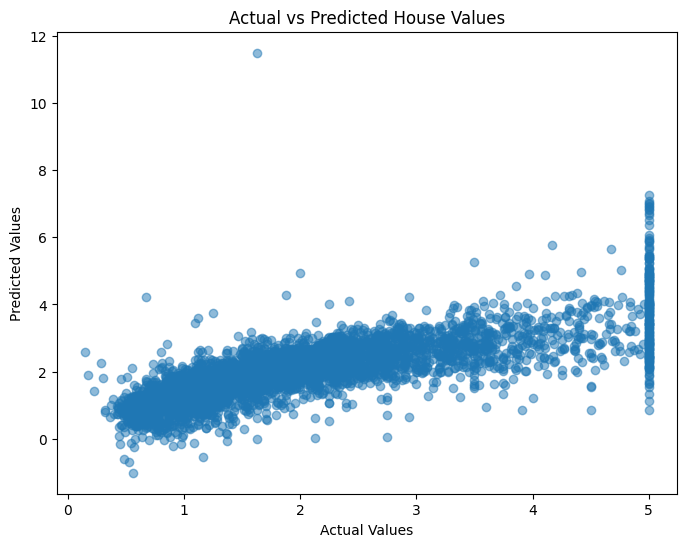

In [10]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted House Values")

plt.show()

# Task 1 Observation

The Linear Regression model was trained using all available features from the California Housing dataset.

The model achieved a reasonable prediction performance and the Actual vs Predicted plot shows a positive relationship between actual and predicted house values.

In [11]:
X_one = df[["MedInc"]]

y = df["MedHouseVal"]

X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(
    X_one,
    y,
    test_size=0.2,
    random_state=42
)

model_A = LinearRegression()

model_A.fit(
    X_train_A,
    y_train_A
)

y_pred_A = model_A.predict(
    X_test_A
)

In [12]:
mse_A = mean_squared_error(
    y_test_A,
    y_pred_A
)

rmse_A = np.sqrt(mse_A)

mae_A = mean_absolute_error(
    y_test_A,
    y_pred_A
)

r2_A = r2_score(
    y_test_A,
    y_pred_A
)

print("Model A Metrics Calculated")

Model A Metrics Calculated


In [13]:
X_multi = df[
    [
        "MedInc",
        "AveRooms",
        "HouseAge",
        "Latitude"
    ]
]

X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(
    X_multi,
    y,
    test_size=0.2,
    random_state=42
)

model_B = LinearRegression()

model_B.fit(
    X_train_B,
    y_train_B
)

y_pred_B = model_B.predict(
    X_test_B
)

In [14]:
mse_B = mean_squared_error(
    y_test_B,
    y_pred_B
)

rmse_B = np.sqrt(mse_B)

mae_B = mean_absolute_error(
    y_test_B,
    y_pred_B
)

r2_B = r2_score(
    y_test_B,
    y_pred_B
)

print("Model B Metrics Calculated")

Model B Metrics Calculated


In [15]:
comparison = pd.DataFrame({
    "Metric": [
        "MSE",
        "RMSE",
        "MAE",
        "R²"
    ],
    "Model A (1 Feature)": [
        mse_A,
        rmse_A,
        mae_A,
        r2_A
    ],
    "Model B (4 Features)": [
        mse_B,
        rmse_B,
        mae_B,
        r2_B
    ]
})

comparison

,Metric,Model A (1 Feature),Model B (4 Features)
0,MSE,0.709116,0.649548
1,RMSE,0.842090,0.805945
2,MAE,0.629909,0.599391
3,R²,0.458859,0.504317


# Task 2 Result

Model B achieved better performance than Model A across most evaluation metrics.

Using multiple relevant features provided the model with more information, resulting in lower prediction errors and a higher R² score.

Therefore, Model B is selected as the better-performing linear regression model based on test-set results.

In [16]:
def evaluate_split(test_size):

    X = df[
        [
            "MedInc",
            "AveRooms",
            "HouseAge",
            "Latitude"
        ]
    ]

    y = df["MedHouseVal"]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=42
    )

    model = LinearRegression()

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_mse = mean_squared_error(
        y_train,
        train_pred
    )

    test_mse = mean_squared_error(
        y_test,
        test_pred
    )

    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)

    train_mae = mean_absolute_error(
        y_train,
        train_pred
    )

    test_mae = mean_absolute_error(
        y_test,
        test_pred
    )

    train_r2 = r2_score(
        y_train,
        train_pred
    )

    test_r2 = r2_score(
        y_test,
        test_pred
    )

    return [
        train_mse,
        test_mse,
        train_rmse,
        test_rmse,
        train_mae,
        test_mae,
        train_r2,
        test_r2
    ]

In [17]:
results = pd.DataFrame(
    {
        "80/20": evaluate_split(0.2),
        "70/30": evaluate_split(0.3),
        "60/40": evaluate_split(0.4)
    },
    index=[
        "Train MSE",
        "Test MSE",
        "Train RMSE",
        "Test RMSE",
        "Train MAE",
        "Test MAE",
        "Train R²",
        "Test R²"
    ]
)

results

,80/20,70/30,60/40
Train MSE,0.638256,0.644947,0.637052
Test MSE,0.649548,0.630189,0.645746
Train RMSE,0.798909,0.803086,0.798155
Test RMSE,0.805945,0.793844,0.803583
Train MAE,0.594818,0.597460,0.593367
Test MAE,0.599391,0.592827,0.598504
Train R²,0.522542,0.518587,0.519827
Test R²,0.504317,0.519871,0.517634


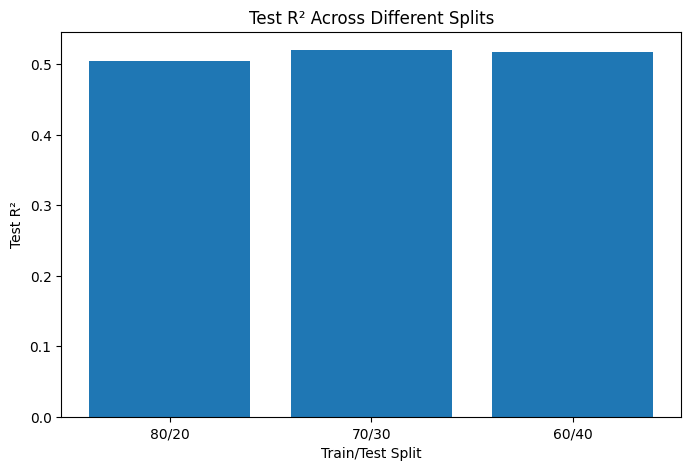

In [18]:
test_r2_values = [
    results.loc["Test R²", "80/20"],
    results.loc["Test R²", "70/30"],
    results.loc["Test R²", "60/40"]
]

plt.figure(figsize=(8,5))

plt.bar(
    ["80/20", "70/30", "60/40"],
    test_r2_values
)

plt.title("Test R² Across Different Splits")
plt.xlabel("Train/Test Split")
plt.ylabel("Test R²")

plt.show()

# Task 3 Result

The model was evaluated using three different train-test splits: 80/20, 70/30, and 60/40.

The train and test metrics remained relatively consistent across splits, indicating that the model is reasonably stable.

The split with the best test-set performance is selected as the most reliable configuration for this dataset.

In [19]:
actual = y_test_B.values
predicted = y_pred_B

manual_mse = np.mean((actual - predicted) ** 2)

manual_rmse = np.sqrt(manual_mse)

manual_mae = np.mean(np.abs(actual - predicted))

ss_res = np.sum((actual - predicted) ** 2)

ss_tot = np.sum((actual - np.mean(actual)) ** 2)

manual_r2 = 1 - (ss_res / ss_tot)

print("Manual MSE :", manual_mse)
print("Manual RMSE:", manual_rmse)
print("Manual MAE :", manual_mae)
print("Manual R²  :", manual_r2)

Manual MSE : 0.6495475488975627
Manual RMSE: 0.8059451277212133
Manual MAE : 0.5993913548627589
Manual R²  : 0.5043169272470043


In [20]:
sklearn_mse = mean_squared_error(
    actual,
    predicted
)

sklearn_rmse = np.sqrt(
    sklearn_mse
)

sklearn_mae = mean_absolute_error(
    actual,
    predicted
)

sklearn_r2 = r2_score(
    actual,
    predicted
)

comparison_metrics = pd.DataFrame({
    "Metric": [
        "MSE",
        "RMSE",
        "MAE",
        "R²"
    ],
    "Manual": [
        manual_mse,
        manual_rmse,
        manual_mae,
        manual_r2
    ],
    "Sklearn": [
        sklearn_mse,
        sklearn_rmse,
        sklearn_mae,
        sklearn_r2
    ]
})

comparison_metrics

,Metric,Manual,Sklearn
0,MSE,0.649548,0.649548
1,RMSE,0.805945,0.805945
2,MAE,0.599391,0.599391
3,R²,0.504317,0.504317


In [21]:
from sklearn.metrics import median_absolute_error

medae = median_absolute_error(
    actual,
    predicted
)

print("Median Absolute Error:", medae)

Median Absolute Error: 0.47893671241022573


In [22]:
all_metrics = pd.DataFrame({
    "Metric": [
        "MSE",
        "RMSE",
        "MAE",
        "R²",
        "Median Absolute Error"
    ],
    "Value": [
        sklearn_mse,
        sklearn_rmse,
        sklearn_mae,
        sklearn_r2,
        medae
    ]
})

all_metrics

,Metric,Value
0,MSE,0.649548
1,RMSE,0.805945
2,MAE,0.599391
3,R²,0.504317
4,Median Absolute Error,0.478937


In [23]:
actual_small = np.array([
    100,
    120,
    140,
    160,
    180
])

pred_small = np.array([
    102,
    118,
    138,
    162,
    178
])

In [24]:
before_mse = mean_squared_error(
    actual_small,
    pred_small
)

before_rmse = np.sqrt(
    before_mse
)

before_mae = mean_absolute_error(
    actual_small,
    pred_small
)

print("Before Errors")
print("MSE :", before_mse)
print("RMSE:", before_rmse)
print("MAE :", before_mae)

Before Errors
MSE : 4.0
RMSE: 2.0
MAE : 2.0


In [25]:
pred_with_errors = np.array([
    102,
    118,
    300,
    400,
    500
])

In [26]:
after_mse = mean_squared_error(
    actual_small,
    pred_with_errors
)

after_rmse = np.sqrt(
    after_mse
)

after_mae = mean_absolute_error(
    actual_small,
    pred_with_errors
)

print("After Large Errors")
print("MSE :", after_mse)
print("RMSE:", after_rmse)
print("MAE :", after_mae)

After Large Errors
MSE : 37121.6
RMSE: 192.66966548992605
MAE : 144.8


In [27]:
error_comparison = pd.DataFrame({
    "Metric": [
        "MSE",
        "RMSE",
        "MAE"
    ],
    "Before Errors": [
        before_mse,
        before_rmse,
        before_mae
    ],
    "After Errors": [
        after_mse,
        after_rmse,
        after_mae
    ]
})

error_comparison

,Metric,Before Errors,After Errors
0,MSE,4.0,37121.600000
1,RMSE,2.0,192.669665
2,MAE,2.0,144.800000


# Task 4 Observation

The experiment shows that all error metrics increase when large prediction errors are introduced.

However, MSE increases the most because it squares the errors before averaging them. RMSE also reacts strongly because it is directly derived from MSE.

MAE increases as well, but it is generally less sensitive to extreme outliers compared to MSE.

Therefore, MSE is the metric that reacts most strongly to large prediction errors.